In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt



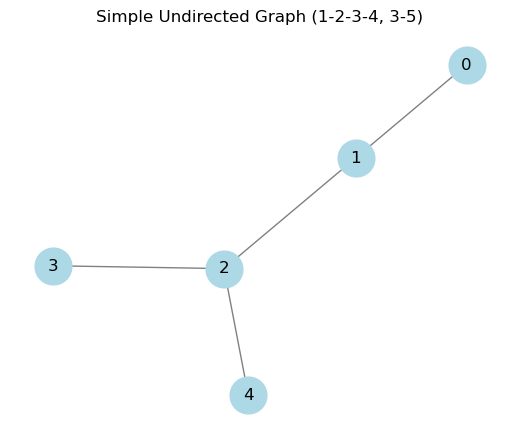

In [2]:
# Define adjacency matrix for 5 nodes (undirected)
adj_matrix = np.zeros((5, 5), dtype=int)
adj_matrix[0, 1] = 1  # 1 - 2
adj_matrix[1, 2] = 1  # 2 - 3
adj_matrix[2, 3] = 1  # 3 - 4
adj_matrix[2, 4] = 1  # 3 - 5

# Make the matrix symmetric for undirected graph
adj_matrix = adj_matrix + adj_matrix.T

# Create undirected graph from adjacency matrix
G = nx.from_numpy_array(adj_matrix)

# Plot the graph
plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700, edge_color='gray')
plt.title('Simple Undirected Graph (1-2-3-4, 3-5)')
plt.show()

In [3]:
node_features = np.array([[1,0,0,0,0]]).T

adj_matrix=adj_matrix+np.eye(5)


degree_matrix=np.diag(np.sum(adj_matrix, axis=0))

degree_matrix_inv_sqrt=np.diag(1/np.sqrt(np.sum(adj_matrix, axis=0)))

degree_matrix_inv_sqrt




A_hat=np.matmul(degree_matrix_inv_sqrt, np.matmul(adj_matrix, degree_matrix_inv_sqrt))

# Let's normalize A_hat column-wise to make sure it preserves the sum of the node features:
A_hat_normalized=np.zeros((5,5))

#for i in range(5):
#    A_hat_normalized[i,:]=A_hat[i,:]/np.sum(A_hat[i,:])

for i in range(5):     
    A_hat_normalized[:,i]=A_hat[:,i]/np.sum(A_hat[:,i])



In [4]:
print(A_hat_normalized)

[[0.55051026 0.39625878 0.         0.         0.        ]
 [0.44948974 0.32354394 0.23172205 0.         0.        ]
 [0.         0.28019727 0.20067718 0.41421356 0.41421356]
 [0.         0.         0.28380039 0.58578644 0.        ]
 [0.         0.         0.28380039 0.         0.58578644]]


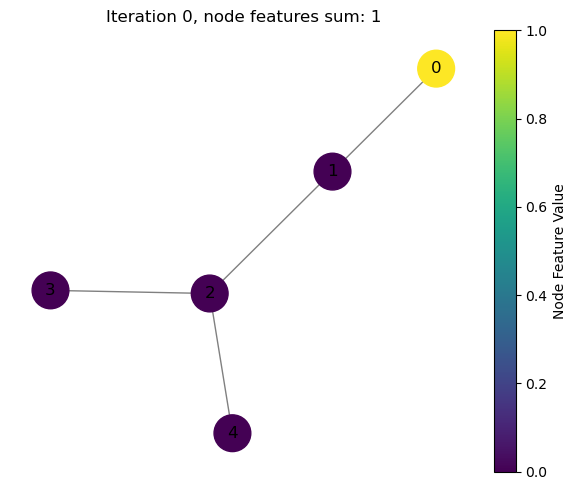

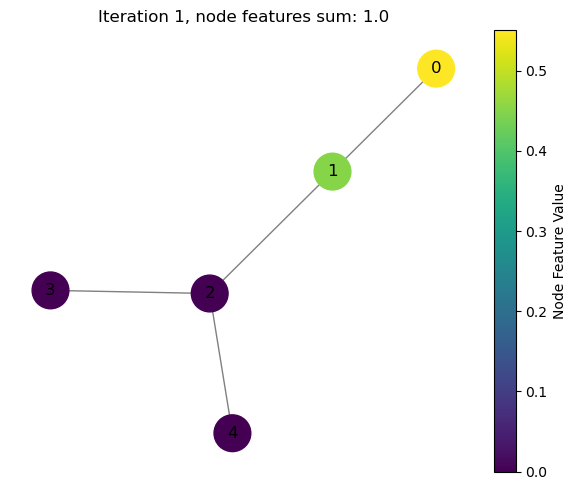

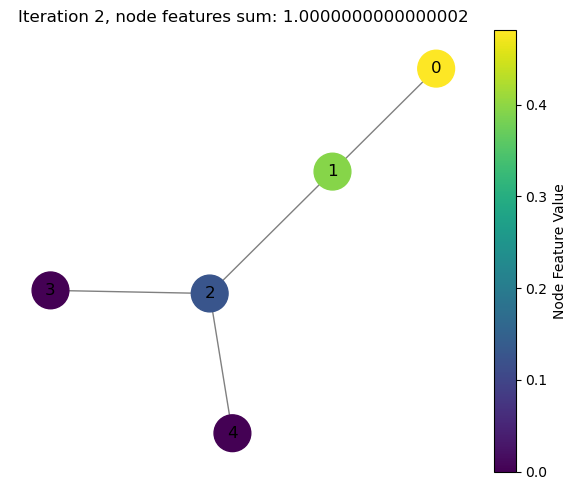

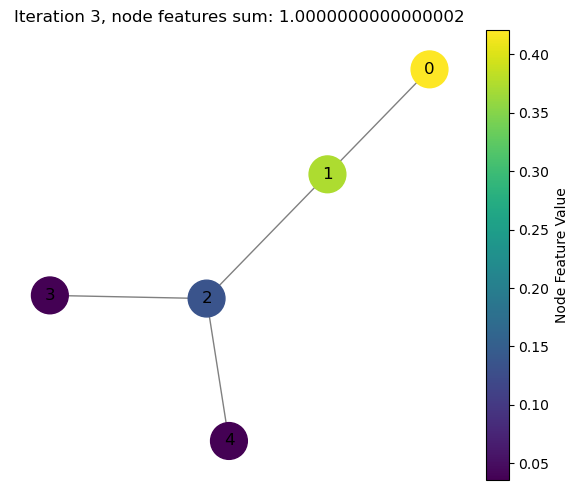

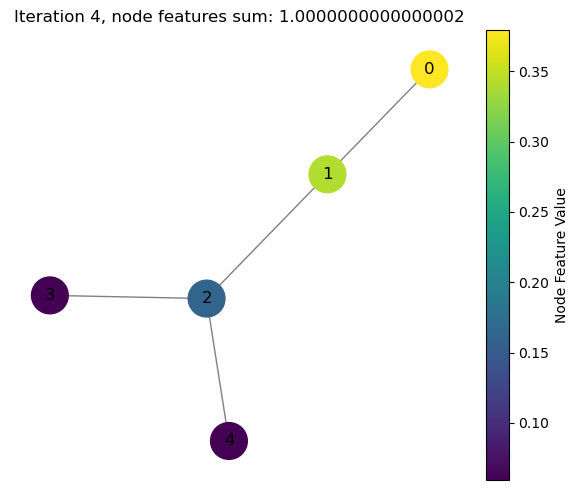

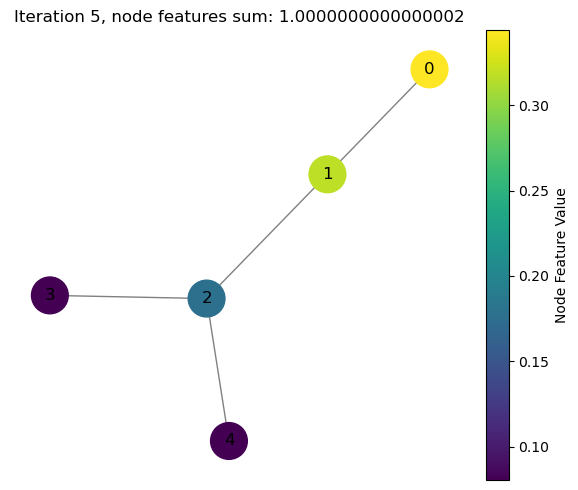

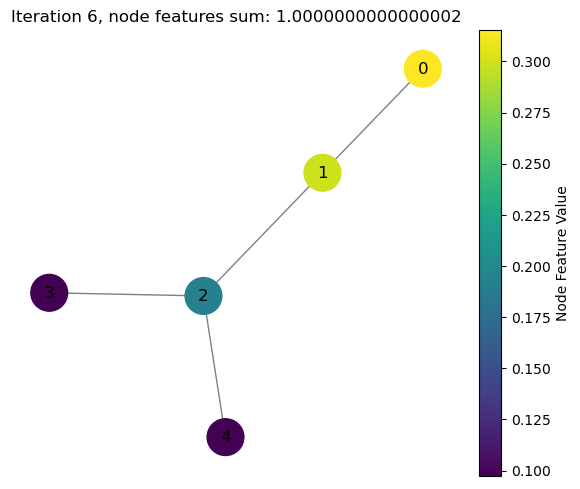

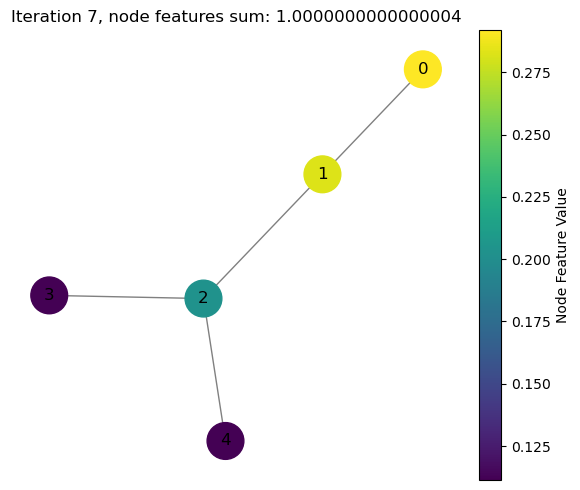

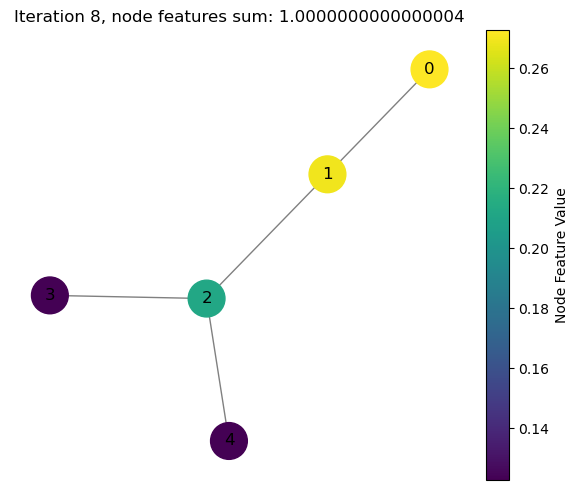

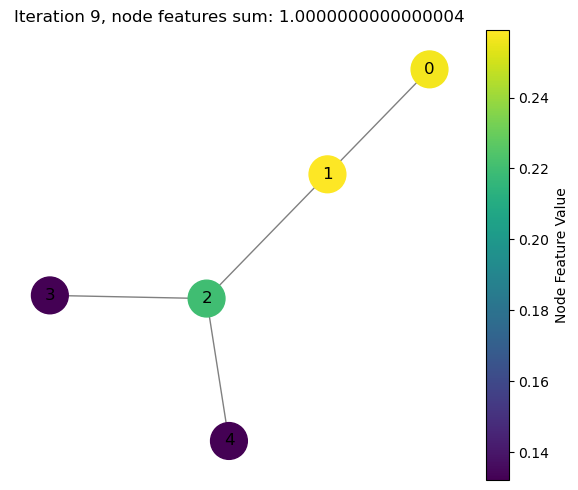

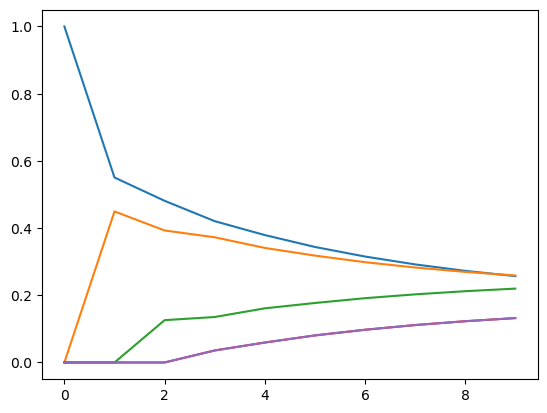

In [5]:
iterations=10

node_features_timeseries=np.zeros((iterations,5))

for i in range(iterations):
    fig, ax = plt.subplots(figsize=(6, 5))
    pos = nx.spring_layout(G, seed=42)

    # Draw the graph with node colors representing features
    nodes = nx.draw_networkx_nodes(
        G, pos, node_color=node_features, cmap='viridis', node_size=700, ax=ax
    )
    nx.draw_networkx_edges(G, pos, edge_color='gray', ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    # Add colorbar, specifying the axes
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=node_features.min(), vmax=node_features.max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.03)
    cbar.set_label('Node Feature Value')

    ax.set_title(f'Iteration {i}, node features sum: {np.sum(node_features)}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    node_features_timeseries[i,:]=node_features.squeeze()

    node_features=np.matmul(A_hat_normalized, node_features)

plt.plot(node_features_timeseries)
plt.show()

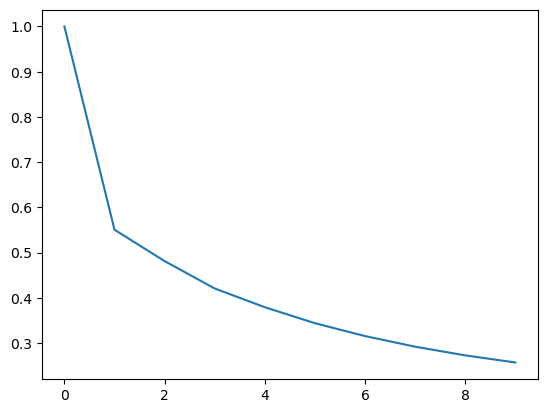

In [6]:
plt.plot(node_features_timeseries[:,0])

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Graph and adjacency matrix
num_nodes = 5
adj_matrix = np.zeros((num_nodes, num_nodes), dtype=int)
adj_matrix[0, 1] = 1
adj_matrix[1, 2] = 1
adj_matrix[2, 3] = 1
adj_matrix[2, 4] = 1
adj_matrix = adj_matrix + adj_matrix.T
A = torch.tensor(adj_matrix, dtype=torch.float32)

# 2. Normalized adjacency (A_hat)
I = torch.eye(A.size(0))
A_hat = A + I
D_hat = torch.diag(torch.sum(A_hat, dim=1) ** -0.5)
A_hat_norm = D_hat @ A_hat @ D_hat

# 3. Generate multiple time series with different initial conditions
num_series = 10000
series_length = 10
all_X = []
all_Y = []

for _ in range(num_series):
    x = torch.randn(num_nodes,)  # new initial condition
    series = []
    for t in range(series_length):
        series.append(x.clone())
        x = A_hat_norm @ x
    series = torch.stack(series)  # [series_length, num_nodes, 1]
    all_X.append(series[:-1])     # [series_length-1, num_nodes, 1]
    all_Y.append(series[1:])      # [series_length-1, num_nodes, 1]

X = torch.stack(all_X)  # [num_series, series_length-1, num_nodes, 1]
Y = torch.stack(all_Y)  # [num_series, series_length-1, num_nodes, 1]

# 4. Train/test split by series
split_idx = int(0.8 * num_series)
X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]


In [20]:
X_train.shape, len(all_X)

(torch.Size([8000, 9, 5]), 10000)

In [28]:
X_train2=X_train.reshape(X_train.shape[0]*X_train.shape[1],X_train.shape[2])
Y_train2=Y_train.reshape(Y_train.shape[0]*Y_train.shape[1],Y_train.shape[2])

X_test2=X_test.reshape(X_test.shape[0]*X_test.shape[1],X_test.shape[2])
Y_test2=Y_test.reshape(Y_test.shape[0]*Y_test.shape[1],Y_test.shape[2])

X_train2.shape, Y_train2.shape


(torch.Size([72000, 5]), torch.Size([72000, 5]))

/home/henriks/miniconda3/envs/AIFS/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


Train RMSE per node: [np.float32(0.011196441), np.float32(0.017437387), np.float32(0.023778643), np.float32(0.010867086), np.float32(0.010432306)]
Test RMSE per node: [np.float32(0.023584556), np.float32(0.028423406), np.float32(0.036565013), np.float32(0.024127573), np.float32(0.022070043)]


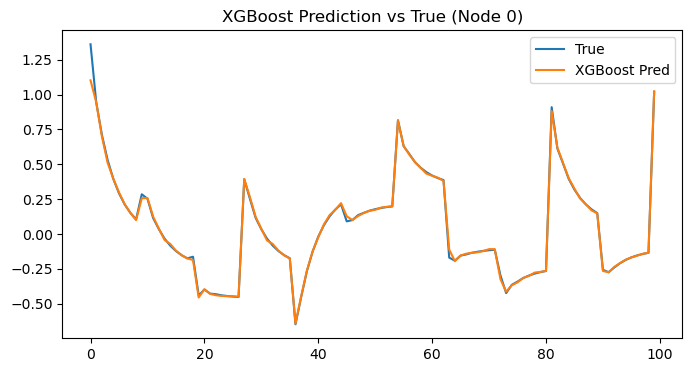

In [51]:
# Build simple XGBoost to learn Y_train2 from X_train2

import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

# XGBoost expects numpy arrays
X_train_np = X_train2.numpy()
Y_train_np = Y_train2.numpy()
X_test_np = X_test2.numpy()
Y_test_np = Y_test2.numpy()

# We'll train one regressor per output node (multi-output regression)
models = []
train_preds = []
test_preds = []
train_rmse = []
test_rmse = []

for i in range(Y_train_np.shape[1]):
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
    model.fit(X_train_np, Y_train_np[:, i])
    models.append(model)
    # Predict on train and test
    train_pred = model.predict(X_train_np)
    test_pred = model.predict(X_test_np)
    train_preds.append(train_pred)
    test_preds.append(test_pred)
    # Compute RMSE
    train_rmse.append(np.sqrt(np.mean((train_pred - Y_train_np[:, i])**2)))
    test_rmse.append(np.sqrt(np.mean((test_pred - Y_test_np[:, i])**2)))

print("Train RMSE per node:", train_rmse)
print("Test RMSE per node:", test_rmse)

# Optionally, plot predictions vs true for one node
plt.figure(figsize=(8,4))
plt.plot(Y_test_np[:100, 0], label='True')
plt.plot(test_preds[0][:100], label='XGBoost Pred')
plt.title("XGBoost Prediction vs True (Node 0)")
plt.legend()
plt.show()


In [70]:
# Build simple MLP to learn Y_train2 from X_train2

import torch
import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x



### BETWEEN HERE AND BELOW, WE'LL TRY TO BUILD A GNN THAT LEARNS Y_train2 FROM X_train2


from torch_geometric.nn import GCNConv

class SimpleGNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleGNN, self).__init__()
        self.conv1 = GCNConv(input_size, hidden_size)
        self.conv2 = GCNConv(hidden_size, output_size)

    def forward(self, x, edge_index):
        # x: [num_nodes, input_size] or [batch*num_nodes, input_size]
        # edge_index: [2, num_edges]
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

## HERE ENDS SIMPLE GNN and BELOW WE'LL TRY TO BUILD A MEAN AGGREGATOR GNN

from torch_geometric.nn import MessagePassing
import torch
import torch.nn as nn
import torch.nn.functional as F

class MeanAggregatorGNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MeanAggregatorGNN, self).__init__()
        self.message1 = MeanMessageLayer(input_size, hidden_size)
        self.message2 = MeanMessageLayer(hidden_size, output_size)

    def forward(self, x, edge_index):
        x = self.message1(x, edge_index)
        x = F.relu(x)
        x = self.message2(x, edge_index)
        return x


class MeanMessageLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='mean')  # 👈 mean aggregation
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index):
        # x: [num_nodes, in_channels]
        x = self.linear(x)  # apply linear before message passing
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        return x_j  # message is just the neighbor's transformed feature

    def update(self, aggr_out):
        return aggr_out  # optionally apply nonlinearity or residual here




#### GNN CLASS ENDS HERE


Epoch 0, Train Loss: 0.350805
Epoch 20, Train Loss: 0.103096
Epoch 40, Train Loss: 0.036780
Epoch 60, Train Loss: 0.017462
Epoch 80, Train Loss: 0.010289
Epoch 100, Train Loss: 0.007092
Epoch 120, Train Loss: 0.005446
Epoch 140, Train Loss: 0.004218
Epoch 160, Train Loss: 0.003273
Epoch 180, Train Loss: 0.002570
Epoch 200, Train Loss: 0.002070
Epoch 220, Train Loss: 0.001707
Epoch 240, Train Loss: 0.001439
Epoch 260, Train Loss: 0.001235
Epoch 280, Train Loss: 0.001076
Epoch 300, Train Loss: 0.000947
Epoch 320, Train Loss: 0.000839
Epoch 340, Train Loss: 0.000732
Epoch 360, Train Loss: 0.000647
Epoch 380, Train Loss: 0.000579
Epoch 400, Train Loss: 0.000520
Epoch 420, Train Loss: 0.000468
Epoch 440, Train Loss: 0.000422
Epoch 460, Train Loss: 0.000382
Epoch 480, Train Loss: 0.000346
Epoch 500, Train Loss: 0.000313
Epoch 520, Train Loss: 0.000282
Epoch 540, Train Loss: 0.000253
Epoch 560, Train Loss: 0.000226
Epoch 580, Train Loss: 0.000202
Epoch 600, Train Loss: 0.000180
Epoch 620, Tra

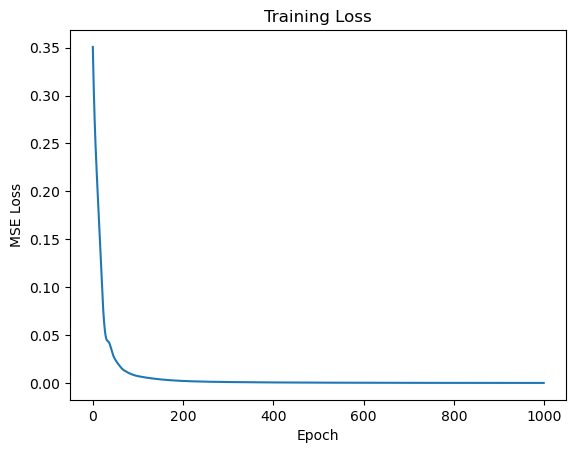

Test MSE Loss: 0.000020


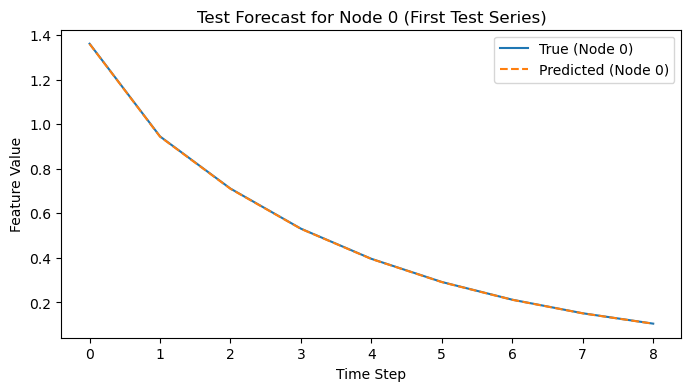

In [68]:


model = MLP(input_size=5, hidden_size=10, output_size=5)

optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop for X_train2, Y_trloss_fn = nn.MSELoss()

losses = []
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    # Flatten batch and time for training: [batch*time, num_nodes, 1]
    Xb = X_train2.reshape(-1, num_nodes)
    Yb = Y_train2.reshape(-1, num_nodes)
    y_pred = model(Xb)
    loss = loss_fn(y_pred, Yb)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Train Loss: {loss.item():.6f}")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# 7. Evaluate on test set
model.eval()
with torch.no_grad():
    Xb_test = X_test2.reshape(-1, num_nodes)
    Yb_test = Y_test2.reshape(-1, num_nodes)
    y_test_pred = model(Xb_test)
    test_loss = loss_fn(y_test_pred, Yb_test).item()
    print(f"Test MSE Loss: {test_loss:.6f}")

# 8. Visualize prediction vs. ground truth for one node in one test series
with torch.no_grad():
    # Pick the first test series
    y_pred_series = model(X_test[0]).squeeze(-1).numpy()  # [series_length-1, num_nodes]
    y_true_series = Y_test[0].squeeze(-1).numpy()

plt.figure(figsize=(8, 4))
plt.plot(y_true_series[:, 0], label='True (Node 0)')
plt.plot(y_pred_series[:, 0], label='Predicted (Node 0)', linestyle='--')
plt.legend()
plt.title("Test Forecast for Node 0 (First Test Series)")
plt.xlabel("Time Step")
plt.ylabel("Feature Value")
plt.show()




In [62]:
edge_index = (torch.tensor(adj_matrix) > 0).nonzero(as_tuple=False).t().contiguous()

Y_test.shape, Y_test2.shape, Y_test[0].shape, edge_index

(torch.Size([2000, 9, 5]),
 torch.Size([18000, 5]),
 torch.Size([9, 5]),
 tensor([[0, 1, 1, 2, 2, 2, 3, 4],
         [1, 0, 2, 1, 3, 4, 2, 2]]))

Epoch 0, Train Loss: 0.558924
Epoch 20, Train Loss: 0.179278
Epoch 40, Train Loss: 0.085542
Epoch 60, Train Loss: 0.057159
Epoch 80, Train Loss: 0.045691
Epoch 100, Train Loss: 0.033171
Epoch 120, Train Loss: 0.023135
Epoch 140, Train Loss: 0.017726
Epoch 160, Train Loss: 0.014592
Epoch 180, Train Loss: 0.012671
Epoch 200, Train Loss: 0.011388
Epoch 220, Train Loss: 0.010436
Epoch 240, Train Loss: 0.009640
Epoch 260, Train Loss: 0.008898
Epoch 280, Train Loss: 0.008136
Epoch 300, Train Loss: 0.007311
Epoch 320, Train Loss: 0.006429
Epoch 340, Train Loss: 0.005551
Epoch 360, Train Loss: 0.004764
Epoch 380, Train Loss: 0.004132
Epoch 400, Train Loss: 0.003663
Epoch 420, Train Loss: 0.003323
Epoch 440, Train Loss: 0.003073
Epoch 460, Train Loss: 0.002885
Epoch 480, Train Loss: 0.002739
Epoch 500, Train Loss: 0.002620
Epoch 520, Train Loss: 0.002521
Epoch 540, Train Loss: 0.002433
Epoch 560, Train Loss: 0.002356
Epoch 580, Train Loss: 0.002286
Epoch 600, Train Loss: 0.002221
Epoch 620, Tra

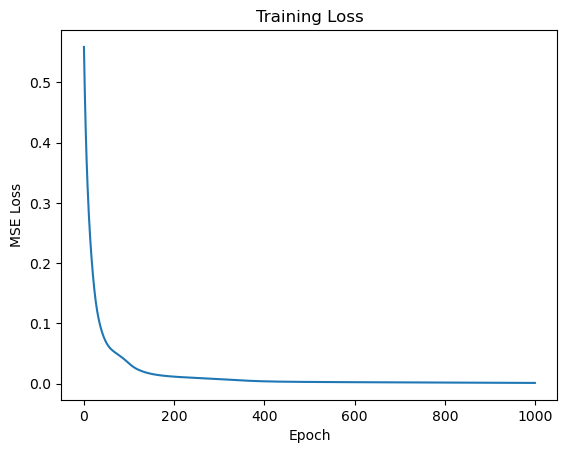

Test MSE Loss: 0.000997


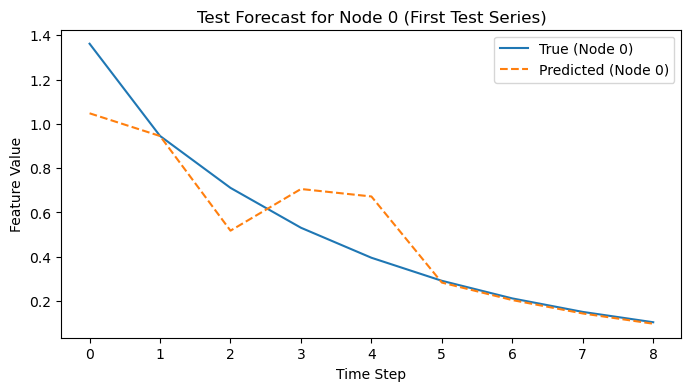

In [67]:
model = SimpleGNN(input_size=5, hidden_size=5, output_size=5)

optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop for X_train2, Y_trloss_fn = nn.MSELoss()

losses = []
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    # Flatten batch and time for training: [batch*time, num_nodes, 1]
    Xb = X_train2.reshape(-1, num_nodes)
    Yb = Y_train2.reshape(-1, num_nodes)
    y_pred = model(Xb, edge_index)
    loss = loss_fn(y_pred, Yb)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Train Loss: {loss.item():.6f}")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# 7. Evaluate on test set
model.eval()
with torch.no_grad():
    Xb_test = X_test2.reshape(-1, num_nodes)
    Yb_test = Y_test2.reshape(-1, num_nodes)
    y_test_pred = model(Xb_test, edge_index)
    test_loss = loss_fn(y_test_pred, Yb_test).item()
    print(f"Test MSE Loss: {test_loss:.6f}")

# 8. Visualize prediction vs. ground truth for one node in one test series
with torch.no_grad():
    # Pick the first test series
    y_pred_series = model(X_test[0], edge_index).squeeze(-1).numpy()  # [series_length-1, num_nodes]
    y_true_series = Y_test[0].squeeze(-1).numpy()

plt.figure(figsize=(8, 4))
plt.plot(y_true_series[:, 0], label='True (Node 0)')
plt.plot(y_pred_series[:, 0], label='Predicted (Node 0)', linestyle='--')
plt.legend()
plt.title("Test Forecast for Node 0 (First Test Series)")
plt.xlabel("Time Step")
plt.ylabel("Feature Value")
plt.show()



Epoch 0, Train Loss: 0.241542
Epoch 20, Train Loss: 0.241508
Epoch 40, Train Loss: 0.241506
Epoch 60, Train Loss: 0.241506
Epoch 80, Train Loss: 0.241506
Epoch 100, Train Loss: 0.241506
Epoch 120, Train Loss: 0.241506
Epoch 140, Train Loss: 0.241506
Epoch 160, Train Loss: 0.241506
Epoch 180, Train Loss: 0.241506
Epoch 200, Train Loss: 0.241506
Epoch 220, Train Loss: 0.241506
Epoch 240, Train Loss: 0.241506
Epoch 260, Train Loss: 0.241506
Epoch 280, Train Loss: 0.241506
Epoch 300, Train Loss: 0.241506
Epoch 320, Train Loss: 0.241506
Epoch 340, Train Loss: 0.241506
Epoch 360, Train Loss: 0.241506
Epoch 380, Train Loss: 0.241506
Epoch 400, Train Loss: 0.241506
Epoch 420, Train Loss: 0.241506
Epoch 440, Train Loss: 0.241506
Epoch 460, Train Loss: 0.241506
Epoch 480, Train Loss: 0.241506
Epoch 500, Train Loss: 0.241506
Epoch 520, Train Loss: 0.241506
Epoch 540, Train Loss: 0.241506
Epoch 560, Train Loss: 0.241506
Epoch 580, Train Loss: 0.241506
Epoch 600, Train Loss: 0.241506
Epoch 620, Tra

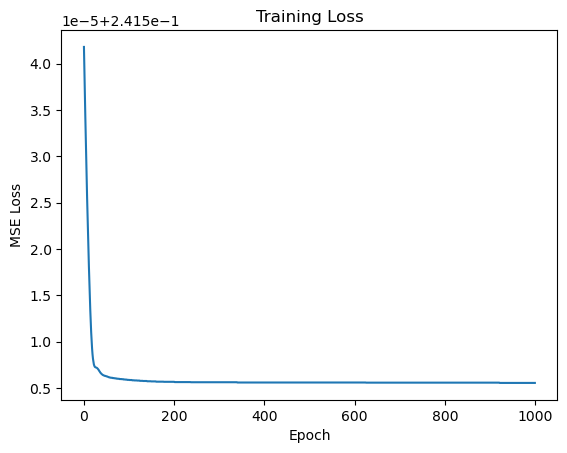

Test MSE Loss: 0.227935


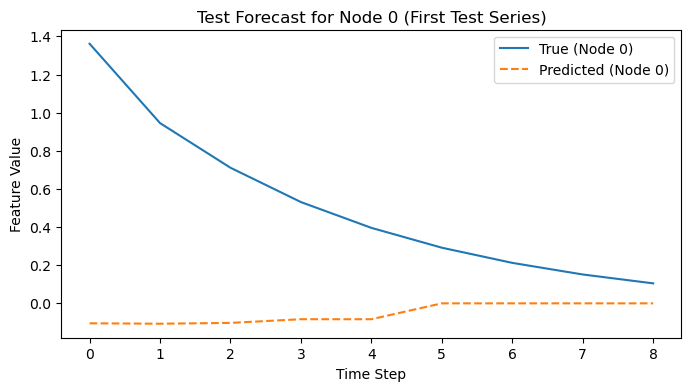

In [71]:
model = MeanAggregatorGNN(input_size=5, hidden_size=5, output_size=5)

optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop for X_train2, Y_trloss_fn = nn.MSELoss()

losses = []
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    # Flatten batch and time for training: [batch*time, num_nodes, 1]
    Xb = X_train2.reshape(-1, num_nodes)
    Yb = Y_train2.reshape(-1, num_nodes)
    y_pred = model(Xb, edge_index)
    loss = loss_fn(y_pred, Yb)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Train Loss: {loss.item():.6f}")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# 7. Evaluate on test set
model.eval()
with torch.no_grad():
    Xb_test = X_test2.reshape(-1, num_nodes)
    Yb_test = Y_test2.reshape(-1, num_nodes)
    y_test_pred = model(Xb_test, edge_index)
    test_loss = loss_fn(y_test_pred, Yb_test).item()
    print(f"Test MSE Loss: {test_loss:.6f}")

# 8. Visualize prediction vs. ground truth for one node in one test series
with torch.no_grad():
    # Pick the first test series
    y_pred_series = model(X_test[0], edge_index).squeeze(-1).numpy()  # [series_length-1, num_nodes]
    y_true_series = Y_test[0].squeeze(-1).numpy()

plt.figure(figsize=(8, 4))
plt.plot(y_true_series[:, 0], label='True (Node 0)')
plt.plot(y_pred_series[:, 0], label='Predicted (Node 0)', linestyle='--')
plt.legend()
plt.title("Test Forecast for Node 0 (First Test Series)")
plt.xlabel("Time Step")
plt.ylabel("Feature Value")
plt.show()


In [60]:
edge_index = (adj_matrix > 0).nonzero(as_tuple=False).t().contiguous().long()


TypeError: ndarray.nonzero() takes no keyword arguments

In [21]:
import torch
from torch_geometric.data import Data

def create_graph_dataset(X, Y, adj_matrix):
    """
    Converts [num_series, time_steps, num_nodes, 1] tensors into PyG Data objects.
    """
    num_series, time_steps, num_nodes, num_features = X.shape

    if not torch.is_tensor(adj_matrix):
        adj_matrix = torch.tensor(adj_matrix)

    edge_index = (adj_matrix > 0).nonzero(as_tuple=False).t().contiguous().long()

    data_list = []

    for s in range(num_series):
        for t in range(time_steps):
            x_t = X[s, t].float()  # shape: [num_nodes, 1]
            y_t = Y[s, t].float()  # shape: [num_nodes, 1]

            # Ensure it's [num_nodes, 1], not [num_nodes] or [num_nodes, 1, 1]
            x_t = x_t.squeeze(-1).unsqueeze(-1)
            y_t = y_t.squeeze(-1).unsqueeze(-1)

            assert x_t.shape == (num_nodes, 1), f"x_t shape: {x_t.shape}"
            assert y_t.shape == (num_nodes, 1), f"y_t shape: {y_t.shape}"

            data = Data(x=x_t, edge_index=edge_index, y=y_t)
            data_list.append(data)

    return data_list



In [22]:
graph_samples = create_graph_dataset(X_train, Y_train, adj_matrix)

# Optional: create test set the same way
graph_test_samples = create_graph_dataset(X_test, Y_test, adj_matrix)

# PyG DataLoader handles batching
from torch_geometric.loader import DataLoader
train_loader = DataLoader(graph_samples, batch_size=32, shuffle=True)
test_loader = DataLoader(graph_test_samples, batch_size=32, shuffle=False)


ValueError: not enough values to unpack (expected 4, got 3)

In [23]:
graph_samples  

[Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8], y=[5, 1]),
 Data(x=[5, 1], edge_index=[2, 8],

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class ProcessorGNN(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=5, output_dim=5, num_layers=4):
        super(ProcessorGNN, self).__init__()

        self.encoder = GCNConv(input_dim, hidden_dim)

        # Processor: stack of message-passing layers (with optional residuals)
        self.processor = nn.ModuleList([
            GCNConv(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])

        self.decoder = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        # Encode
        x = self.encoder(x, edge_index)
        x = F.relu(x)

        # Processor (multiple message passing steps)
        for layer in self.processor:
            residual = x
            x = layer(x, edge_index)
            x = F.relu(x + residual)  # residual connection

        # Decode
        out = self.decoder(x, edge_index)
        return out


In [25]:
import torch
from torch.optim import Adam
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ProcessorGNN(input_dim=5, hidden_dim=5, output_dim=5, num_layers=4).to(device)

optimizer = Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

def train(model, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        loss = loss_fn(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index)
            loss = loss_fn(out, batch.y)
            total_loss += loss.item()
    return total_loss / len(loader)

# Training
epochs = 50
for epoch in range(epochs):
    train_loss = train(model, train_loader)
    test_loss = evaluate(model, test_loader)
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (160x1 and 5x5)

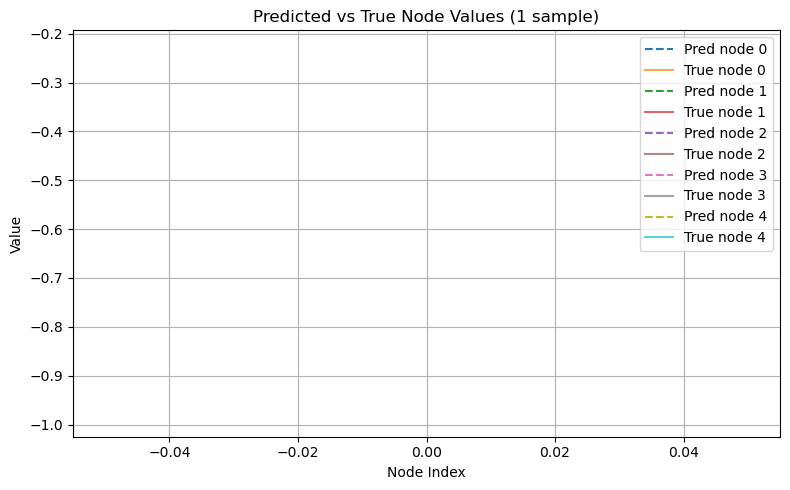

In [12]:
import matplotlib.pyplot as plt

model.eval()

# Take one batch from test loader
batch = next(iter(test_loader))
batch = batch.to(device)

with torch.no_grad():
    preds = model(batch.x, batch.edge_index).cpu().numpy()
    targets = batch.y.cpu().numpy()

# Plot for first graph in batch (PyG batches multiple graphs together)
# We need to extract node-wise predictions for just one graph
batch_size = batch.num_graphs
nodes_per_graph = batch.x.size(0) // batch_size

plt.figure(figsize=(8, 5))
for node in range(min(5, nodes_per_graph)):
    start = 0  # first graph
    plt.plot(preds[start + node], label=f'Pred node {node}', linestyle='--')
    plt.plot(targets[start + node], label=f'True node {node}', alpha=0.7)

plt.legend()
plt.title("Predicted vs True Node Values (1 sample)")
plt.xlabel("Node Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()

In [190]:
batch

DataBatch(x=[160, 1], edge_index=[2, 256], y=[160, 1], batch=[160], ptr=[33])

In [ ]:

# 5. Define deep GNN forecaster
class DeepGNN(nn.Module):
    def __init__(self, num_layers, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(in_dim, hidden_dim))
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.layers.append(nn.Linear(hidden_dim, out_dim))
        self.A_hat = A_hat_norm

    def forward(self, x):
        # x: [batch, num_nodes, in_dim]
        for layer in self.layers[:-1]:
            x = torch.matmul(self.A_hat, x)
            x = F.relu(layer(x))
        x = torch.matmul(self.A_hat, x)
        x = self.layers[-1](x)
        return x

# 6. Training loop
model = DeepGNN(num_layers=3, in_dim=1, hidden_dim=5, out_dim=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

losses = []
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    # Flatten batch and time for training: [batch*time, num_nodes, 1]
    Xb = X_train.reshape(-1, num_nodes, 1)
    Yb = Y_train.reshape(-1, num_nodes, 1)

    #print("Diagnostics Xb shape: ", Xb.shape)
    #print("Diagnostics Yb shape: ", Yb.shape)

    y_pred = model(Xb)

    #print("Diagnostics y_pred.shape: ", y_pred.shape)

    #print("Manually calculated loss: ", torch.mean  ((y_pred-Yb)**2) )
    #print("Manual comparison: ", Xb[0,:,0],y_pred[0,:,0],Yb[0,:,0])
    #print("Manual comparison, easy example 40th element: ", Xb[40,:,0],y_pred[40,:,0],Yb[40,:,0])


    loss = loss_fn(y_pred, Yb)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Train Loss: {loss.item():.6f}")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# 7. Evaluate on test set
model.eval()
with torch.no_grad():
    Xb_test = X_test.reshape(-1, num_nodes, 1)
    Yb_test = Y_test.reshape(-1, num_nodes, 1)
    y_test_pred = model(Xb_test)
    test_loss = loss_fn(y_test_pred, Yb_test).item()
    print(f"Test MSE Loss: {test_loss:.6f}")

# 8. Visualize prediction vs. ground truth for one node in one test series
with torch.no_grad():
    # Pick the first test series
    y_pred_series = model(X_test[0]).squeeze(-1).numpy()  # [series_length-1, num_nodes]
    y_true_series = Y_test[0].squeeze(-1).numpy()

plt.figure(figsize=(8, 4))
plt.plot(y_true_series[:, 0], label='True (Node 0)')
plt.plot(y_pred_series[:, 0], label='Predicted (Node 0)', linestyle='--')
plt.legend()
plt.title("Test Forecast for Node 0 (First Test Series)")
plt.xlabel("Time Step")
plt.ylabel("Feature Value")
plt.show()

In [164]:
X.shape

split_idx

80

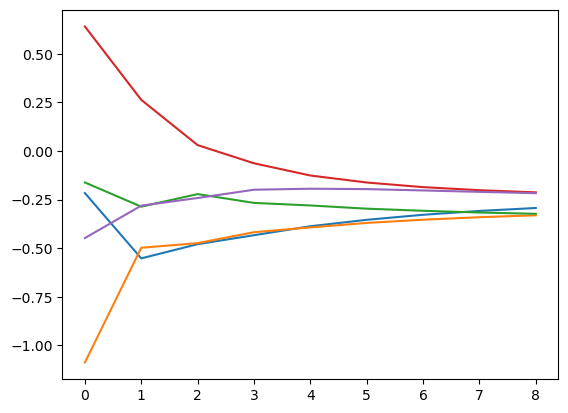

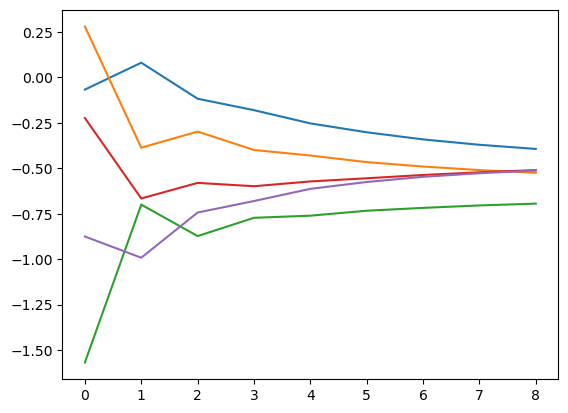

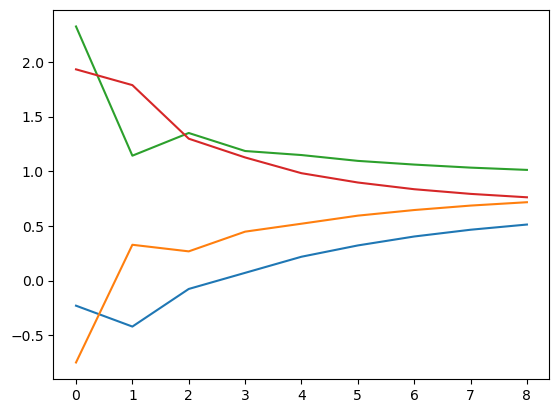

In [187]:
len(all_X)
all_X[0].shape

plt.plot(all_X[0][:,0,0])
plt.plot(all_X[0][:,1,0])
plt.plot(all_X[0][:,2,0])
plt.plot(all_X[0][:,3,0])
plt.plot(all_X[0][:,4,0])
plt.show()

plt.plot(all_X[1][:,0,0])
plt.plot(all_X[1][:,1,0])
plt.plot(all_X[1][:,2,0])
plt.plot(all_X[1][:,3,0])
plt.plot(all_X[1][:,4,0])
plt.show()

plt.plot(all_X[2][:,0,0])
plt.plot(all_X[2][:,1,0])
plt.plot(all_X[2][:,2,0])
plt.plot(all_X[2][:,3,0])

In [145]:
model(torch.tensor([[1.0,0,0,0,0]]).T)

tensor([[0.2991],
        [0.2837],
        [0.1628],
        [0.0587],
        [0.0587]], grad_fn=<AddmmBackward0>)

In [189]:
print(Xb[0,:,0])

print(torch.tensor([[1.0,0,0,0,0]]).T)

print(Xb[0,:,0].shape)
print(torch.tensor([[1.0,0,0,0,0]]).T.shape)

test_tensor=Xb[0,:,0].T.reshape(5,1)

print(model(test_tensor,edge_index))

print("Test data", Xb[0,:,0],Yb[0,:,0])


tensor([-0.3259, -0.3611, -0.6798,  0.9047,  0.1378])
tensor([[1.],
        [0.],
        [0.],
        [0.],
        [0.]])
torch.Size([5])
torch.Size([5, 1])
tensor([[-0.4216],
        [ 0.0159],
        [-0.3215],
        [ 0.2841],
        [ 0.1111]], grad_fn=<AddBackward0>)
Test data tensor([-0.3259, -0.3611, -0.6798,  0.9047,  0.1378]) tensor([-0.3104, -0.4497,  0.0944,  0.2120, -0.1715])


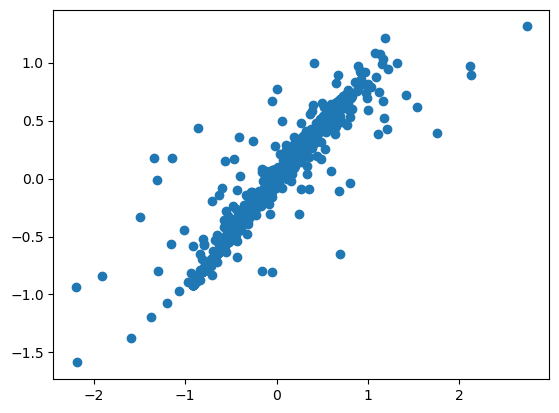

In [156]:
plt.scatter(Xb[:,0,:],Yb[:,0,:])